# TP1 - Vision por Computadora

---
# Enunciado

### Parte 1 (imágenes en `/white_patch`)

1. Implementar el algoritmo White Patch para librarnos de las diferencias de color de iluminación.
2. Mostrar los resultados obtenidos y analizar las posibles fallas, si es que las hay, en el caso de White Patch.

### Parte 2

1. Para las imágenes `img1_tp.png` y `img2_tp.png`, leerlas con OpenCV en escala de grises y visualizarlas.
2. Elegir el número de bins que crea conveniente, graficar su histograma y comparar los histogramas entre sí. Explicar lo que se observa y, si se tuviera que entrenar un modelo de clasificación/detección de imágenes, evaluar si sería útil tomar los histogramas como features.

---
# Resolución

## Parte 1 - White Patch

In [ ]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

In [35]:
# Cargamos las 3 imagenes (Estan en BGR)
img_test_blue = cv.imread('archivos/white_patch/wp_blue.jpg')
img_test_red = cv.imread('archivos/white_patch/wp_red2.jpg')
img_test_green = cv.imread('archivos/white_patch/wp_green2.jpg')

In [36]:
# Convertimos de BGR a RGB
imgRGB_test_blue = cv.cvtColor(img_test_blue, cv.COLOR_BGR2RGB)
imgRGB_test_green = cv.cvtColor(img_test_green, cv.COLOR_BGR2RGB)
imgRGB_test_red = cv.cvtColor(img_test_red, cv.COLOR_BGR2RGB)

In [37]:
# Metodo white patch
# El algoritmo white patch, toma el valor maximo en el canal (R-G-B) y lo lleva al maximo que es 255
# Los demás valores de la matriz se multiplican por el factor de conversion que se aplicó para llevar hasta 255 el max.
# Al multiplicar valores de una matrix por coeficientes, nos da como resultado punto flotante, asi que tenemos
# convertir a unsigned int 8
def white_patch(img):
    R,G,B = cv.split(img)
    R_max = np.max(R)
    G_max = np.max(G)
    B_max = np.max(B)
    print(f"R_max: {R_max}, G_max: {G_max}, B_max: {B_max}")
    R = (R * (255 / R_max)).astype(np.uint8)
    G = (G * (255 / G_max)).astype(np.uint8)
    B = (B * (255 / B_max)).astype(np.uint8)
    img_white_patch = cv.merge((R, G, B))
    return img_white_patch

In [38]:
white_patch_blue = white_patch(imgRGB_test_blue)
white_patch_green = white_patch(imgRGB_test_green)
white_patch_red = white_patch(imgRGB_test_red)

R_max: 255, G_max: 255, B_max: 255
R_max: 170, G_max: 255, B_max: 172
R_max: 255, G_max: 201, B_max: 203


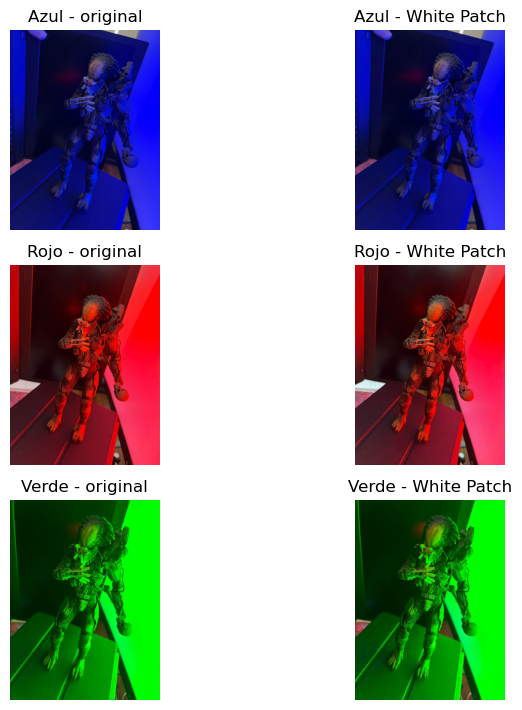

In [ ]:
# Lista con las imágenes
imagenes = [
    {
        "nombre": "Azul",
        "original": imgRGB_test_blue,
        "corregida": white_patch_blue
    },
    {
        "nombre": "Rojo",
        "original": imgRGB_test_red,
        "corregida": white_patch_red
    },
    {
        "nombre": "Verde",
        "original": imgRGB_test_green,
        "corregida": white_patch_green
    }
]

# Ploteo
fig, ejes = plt.subplots(len(imagenes), 2, figsize=(9, 2.4 * len(imagenes)))

for fila, item in enumerate(imagenes):
    ejes[fila, 0].imshow(item["original"])
    ejes[fila, 0].set_title(f"{item['nombre']} - original")
    ejes[fila, 0].axis("off")

    ejes[fila, 1].imshow(item["corregida"])
    ejes[fila, 1].set_title(f"{item['nombre']} - White Patch")
    ejes[fila, 1].axis("off")

plt.tight_layout()
plt.show()

In [40]:
img_hands_blue = cv.imread('archivos/white_patch/test_blue.png')
img_hands_red = cv.imread('archivos/white_patch/test_red.png')
img_hands_green = cv.imread('archivos/white_patch/test_green.png')

In [41]:
imgRGB_hands_blue = cv.cvtColor(img_hands_blue, cv.COLOR_BGR2RGB)
imgRGB_hands_red = cv.cvtColor(img_hands_red, cv.COLOR_BGR2RGB)
imgRGB_hands_green = cv.cvtColor(img_hands_green, cv.COLOR_BGR2RGB)

In [42]:
white_patch_blue_hands = white_patch(imgRGB_hands_blue)
white_patch_green_hands = white_patch(imgRGB_hands_green)
white_patch_red_hands = white_patch(imgRGB_hands_red)

R_max: 165, G_max: 138, B_max: 200
R_max: 210, G_max: 250, B_max: 171
R_max: 247, G_max: 157, B_max: 175


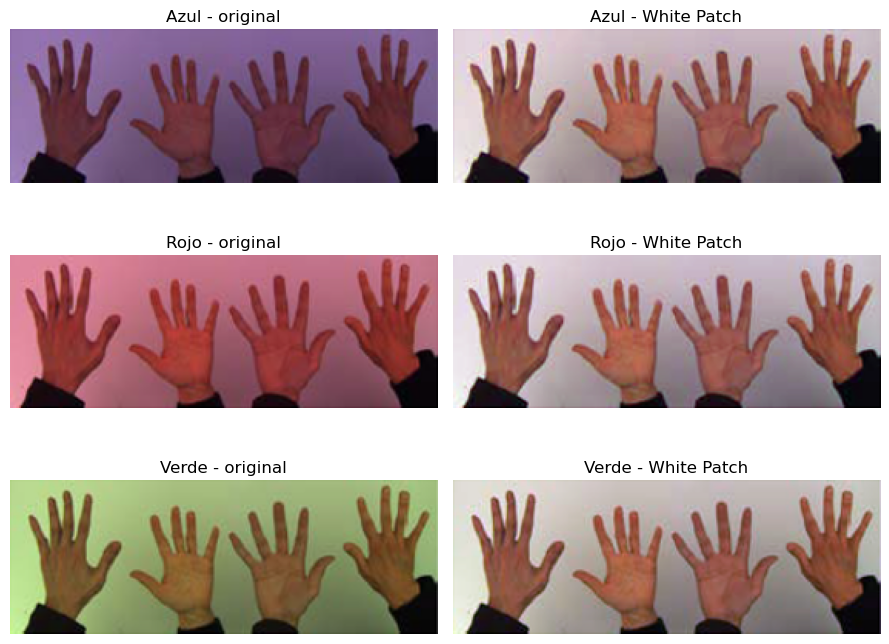

In [ ]:
# Lista con las imágenes 2
imagenes2 = [
    {
        "nombre": "Azul",
        "original": imgRGB_hands_blue,
        "corregida": white_patch_blue_hands
    },
    {
        "nombre": "Rojo",   
        "original": imgRGB_hands_red,
        "corregida": white_patch_red_hands
    },
    {
        "nombre": "Verde",
        "original": imgRGB_hands_green,
        "corregida": white_patch_green_hands
    }
]  

# Ploteo
fig, ejes = plt.subplots(len(imagenes2), 2, figsize=(9, 2.4 * len(imagenes2)))  
for fila, item in enumerate(imagenes2):
    ejes[fila, 0].imshow(item["original"])
    ejes[fila, 0].set_title(f"{item['nombre']} - original")
    ejes[fila, 0].axis("off")

    ejes[fila, 1].imshow(item["corregida"])
    ejes[fila, 1].set_title(f"{item['nombre']} - White Patch")
    ejes[fila, 1].axis("off")
    
plt.tight_layout()
plt.show() 

## 2)Conclusiones
Analizando los resultados, vemos que este algoritmo tiene un inconveniente clave.

El funcionamiento es el siguiente:

Separa la imagen en capas R,G,B y calcula el máximo, luego toma este máximo y lo lleva a 255 para hacerlo blanco, el problema clave de este algoritmo es, si en cualquier lugar de la capa, existe al menos un pixel que tenga valor 255, ese ya será el máximo, por lo tanto multiplicará el resto de la matriz por el factor de conversion, que en este caso será 1. Es decir la imagen permanecera exactamente igual.

Al ejecutar el metodo white patch con las primeras imagenes vemos que en cada 1 de las capas, el maximo es 255 y por el contrario en la imagen de manos, los máximos son inferiores a 255, por lo tanto, se llevan a 255 y se multiplica por un factor de conversion en toda la matriz superior a 1.

En este segundo caso vemos claramente como la imagen cambia, eliminandose las tonalidades, llevandolas a un tono mas blanco.


## Parte 2 - Imágenes en escala de grises

1. Para las imágenes img1_tp.png y img2_tp.png leerlas con OpenCVen escala de grisas y visualizarlas.

In [ ]:
# Cargamos las 2 imagenes
img1 = cv.imread('archivos/img1_tp.png', cv.IMREAD_GRAYSCALE)
img2 = cv.imread('archivos/img2_tp.png', cv.IMREAD_GRAYSCALE)

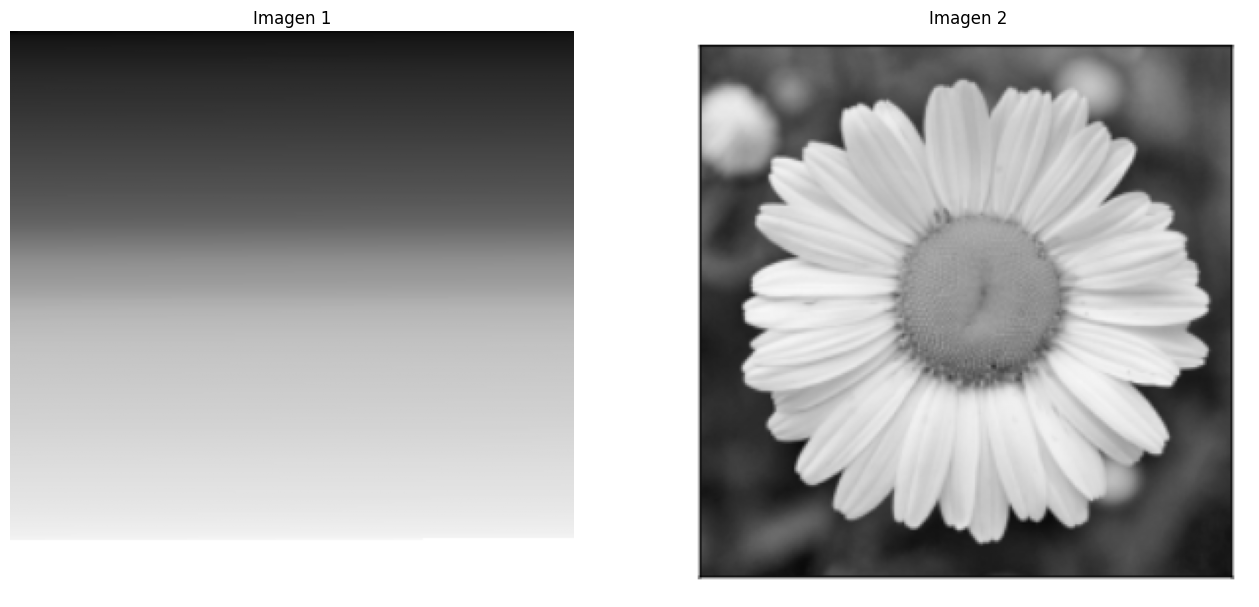

In [ ]:
# Graficamos imagenes originales
sv.plot_images_grid(
    images=[img1, img2],
    grid_size=(1, 2),
    titles=["Imagen 1", "Imagen 2"],
    size=(16, 12)
)

2. Elija el numero de bins que crea conveniente y grafique su histograma, compare los histogramas entre si. Explicar lo que se observa, si tuviera que entrenar un modelo de clasificación/detección de imágenes, considera que puede ser de utilidad tomar como ‘features’ a los histogramas?

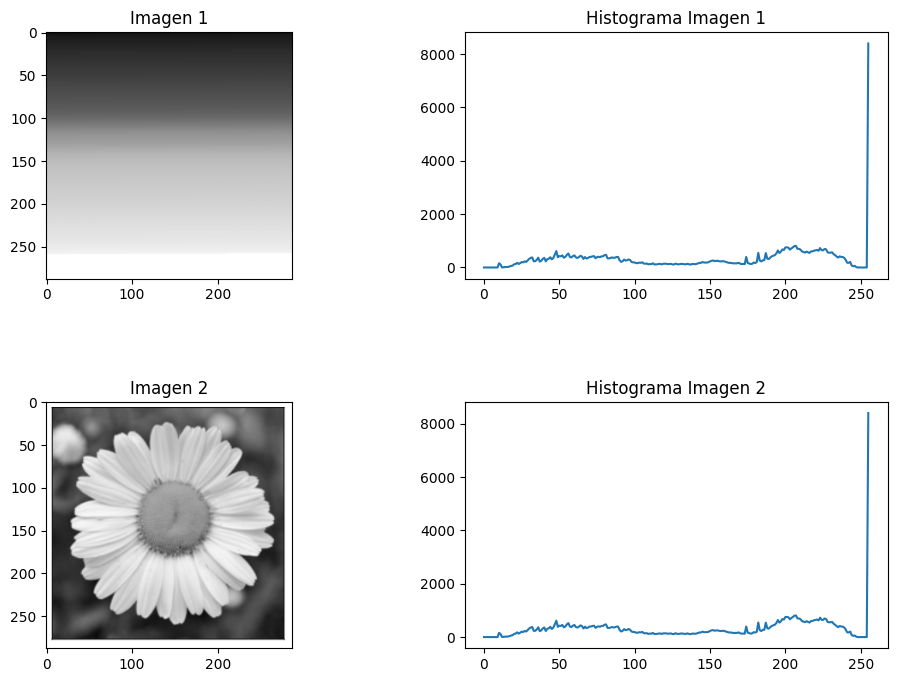

In [ ]:
fig = plt.figure(figsize=(12, 8))

# Imagen 1
ax1=plt.subplot(221)
ax1.imshow(img1, cmap='gray', vmin=0, vmax=255)
ax1.set_title('Imagen 1')

hist1 = cv.calcHist([img1],[0],None,[256],[0,256])
ax2=plt.subplot(222)
ax2.set_title('Histograma Imagen 1')
ax2.plot(hist1)


# Imagen 2
ax3=plt.subplot(223)
ax3.imshow(img2, cmap='gray', vmin=0, vmax=255)
ax3.set_title('Imagen 2')

hist2 = cv.calcHist([img2],[0],None,[256],[0,256])
ax4=plt.subplot(224)
ax4.set_title('Histograma Imagen 2')
ax4.plot(hist2)

plt.subplots_adjust(hspace=0.5)

plt.show()


Al cargar las 2 imagenes con sus histogramas vemos, que aunque ambas fotos sean diferentes, sus histogramas son exactamente iguales. Esto ocurre porque ambas fotos comparten los mismos pixeles pero en diferente orden.

Por lo tanto para entrenar un modelo de clasificación/detección, el histograma no seria válido, ya que no contiene información espacial y podria detectar 2 imagenes visualmente diferentes como iguales y viceversa.